# Hybrid wine recommender

This notebook combines two models:

- TF-IDF
- ALS

Then it tests a weighted hybrid of the two.

The goal is to see if the hybrid works better than either parent model on the same 5000-user sample.

In [ ]:
import warnings
from pathlib import Path
import itertools
import ast
import re

import numpy as np

import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 100)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

POSITIVE_THRESHOLD = 4.0
MIN_POSITIVE_INTERACTIONS = 5
MAX_POSITIVE_INTERACTIONS = 250
MAX_USERS = 5000
TEST_FRACTION = 0.2

ALS_FACTORS = 64
ALS_REGULARIZATION = 0.05
ALS_ITERATIONS = 15
ALS_ALPHA = 40

HYBRID_WEIGHTS = [0.0, 0.25, 0.5, 0.75, 1.0]


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'dataset').exists() and (candidate / 'EDA').exists():
            return candidate
    raise FileNotFoundError('Project root with dataset/ and EDA/ not found')


PROJECT_ROOT = find_project_root(Path.cwd())
DATASET_DIR = PROJECT_ROOT / 'dataset'
EXISTING_SAMPLED_USERS_PATH = PROJECT_ROOT / 'data' / 'results' / 'nonpers_sampled_users_5000.csv'

print('Project root:', PROJECT_ROOT)
print('Dataset dir :', DATASET_DIR)

Project root: /Users/michailsifakis/wine-recommendation-system
Dataset dir : /Users/michailsifakis/wine-recommendation-system/dataset


## 1. Load the data

We use the same setup as the other recommender notebooks.

- ratings 4.0 and above are treated as positive
- users need between 5 and 250 positive ratings
- if the saved 5000-user sample exists, we reuse it

In [2]:
wine_cols = ['WineID', 'WineName', 'Type', 'Country', 'RegionName', 'Body', 'Acidity', 'Grapes', 'Harmonize', 'Elaborate']
rating_cols = ['UserID', 'WineID', 'Rating']

wines = pd.read_csv(
    DATASET_DIR / 'XWines_Full_100K_wines.csv',
    usecols=wine_cols,
    dtype={
        'WineID': 'int32',
        'WineName': 'string',
        'Type': 'category',
        'Country': 'category',
        'RegionName': 'string',
        'Body': 'category',
        'Acidity': 'category',
        'Grapes': 'string',
        'Harmonize': 'string',
        'Elaborate': 'string',
    },
)
ratings = pd.read_csv(
    DATASET_DIR / 'XWines_Full_21M_ratings.csv',
    usecols=rating_cols,
    dtype={'UserID': 'int32', 'WineID': 'int32', 'Rating': 'float32'},
)

wines = wines.drop_duplicates(subset='WineID').copy()
ratings = ratings.drop_duplicates(subset=['UserID', 'WineID']).copy()
ratings = ratings[ratings['WineID'].isin(wines['WineID'])].copy()

positive = ratings[ratings['Rating'] >= POSITIVE_THRESHOLD].copy()
user_counts = positive['UserID'].value_counts()
eligible_users = user_counts[(user_counts >= MIN_POSITIVE_INTERACTIONS) & (user_counts <= MAX_POSITIVE_INTERACTIONS)].index
positive = positive[positive['UserID'].isin(eligible_users)].copy()

if EXISTING_SAMPLED_USERS_PATH.exists():
    sampled_users = pd.read_csv(EXISTING_SAMPLED_USERS_PATH)['UserID'].to_numpy()
    sampled_users = np.intersect1d(sampled_users, positive['UserID'].unique())
else:
    rng = np.random.default_rng(RANDOM_STATE)
    sampled_users = rng.choice(
        positive['UserID'].unique(),
        size=min(MAX_USERS, positive['UserID'].nunique()),
        replace=False,
    )

positive = positive[positive['UserID'].isin(sampled_users)].copy()


def split_train_test_per_user(df, test_fraction=TEST_FRACTION, random_state=RANDOM_STATE):
    train_chunks, test_chunks = [], []
    for _, group in df.groupby('UserID'):
        group = group.sample(frac=1.0, random_state=random_state)
        n_test = max(1, int(np.ceil(len(group) * test_fraction)))
        test_group = group.iloc[:n_test]
        train_group = group.iloc[n_test:]
        if len(train_group) == 0:
            continue
        train_chunks.append(train_group)
        test_chunks.append(test_group)
    return pd.concat(train_chunks, ignore_index=True), pd.concat(test_chunks, ignore_index=True)


train_pos, test_pos = split_train_test_per_user(positive)

print('Wines           :', wines.shape)
print('Ratings         :', ratings.shape)
print('Positive sample :', positive.shape)
print('Train positives :', train_pos.shape)
print('Test positives  :', test_pos.shape)
print('Users           :', train_pos['UserID'].nunique())

Wines           : (100646, 10)
Ratings         : (20590800, 3)
Positive sample : (73319, 3)
Train positives : (56673, 3)
Test positives  : (16646, 3)
Users           : 5000


## 2. Build the TF-IDF model

For each user, we build a profile from the wines they liked in the training set.

This gives us a content-based score for every unseen wine.

In [3]:
def safe_parse_list(value):
    if not isinstance(value, str) or value.strip() == '':
        return []
    try:
        parsed = ast.literal_eval(value)
        if isinstance(parsed, list):
            return [str(x).lower().strip() for x in parsed]
    except Exception:
        pass
    cleaned = re.sub(r"[\[\]']", '', value)
    return [x.lower().strip() for x in cleaned.split(',') if x.strip()]


def build_feature_string(row):
    parts = []
    wine_type = str(row.get('Type', '')).lower().strip()
    parts.extend([wine_type] * 3)

    grapes = safe_parse_list(str(row.get('Grapes', '')))
    parts.extend(grapes * 2)

    harmonize = safe_parse_list(str(row.get('Harmonize', '')))
    parts.extend(harmonize)

    body = str(row.get('Body', '')).lower().strip()
    acidity = str(row.get('Acidity', '')).lower().strip()
    parts.extend([body] * 2)
    parts.append(acidity)

    country = str(row.get('Country', '')).lower().strip()
    region = str(row.get('RegionName', '')).lower().strip()
    parts.extend([country] * 2)
    parts.append(region)

    elaborate = str(row.get('Elaborate', '')).lower().replace('/', ' ').strip()
    parts.append(elaborate)

    return ' '.join(token for token in parts if token and token != 'nan')


wines = wines.fillna('').copy()
wines['feature_str'] = wines.apply(build_feature_string, axis=1)

vectorizer = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
)
item_tfidf = vectorizer.fit_transform(wines['feature_str'])
item_tfidf = normalize(item_tfidf)

wineid_to_idx = pd.Series(np.arange(len(wines)), index=wines['WineID'])
idx_to_wineid = dict(enumerate(wines['WineID'].tolist()))

train_pos = train_pos[train_pos['WineID'].isin(wineid_to_idx.index)].copy()
test_pos = test_pos[test_pos['WineID'].isin(wineid_to_idx.index)].copy()

user_profiles = {}
for user_id, history in train_pos.groupby('UserID'):
    item_indices = history['WineID'].map(wineid_to_idx).to_numpy()
    weights = history['Rating'].to_numpy(dtype='float32')
    profile = item_tfidf[item_indices].multiply(weights[:, None]).sum(axis=0)
    user_profiles[user_id] = normalize(sp.csr_matrix(profile))

train_seen = train_pos.groupby('UserID')['WineID'].apply(set).to_dict()
test_relevant = test_pos.groupby('UserID')['WineID'].apply(set).to_dict()

def score_tfidf_user(user_id):
    profile = user_profiles.get(user_id)
    if profile is None:
        return np.array([])
    return (item_tfidf @ profile.T).toarray().ravel()

print('TF-IDF matrix shape:', item_tfidf.shape)
print('User profiles built :', len(user_profiles))

TF-IDF matrix shape: (100646, 12566)
User profiles built : 5000


## 3. Build the ALS model

This is the collaborative filtering part.

It uses the same ALS idea as the collaborative filtering notebook.

In [4]:
def fit_als_model(
    train_df,
    all_wine_ids,
    factors=ALS_FACTORS,
    regularization=ALS_REGULARIZATION,
    iterations=ALS_ITERATIONS,
    alpha=ALS_ALPHA,
    random_state=RANDOM_STATE,
):
    rng = np.random.default_rng(random_state)

    users = sorted(train_df['UserID'].unique())
    active_wines = sorted(train_df['WineID'].unique())
    user2idx = {user_id: idx for idx, user_id in enumerate(users)}
    item2idx = {wine_id: idx for idx, wine_id in enumerate(active_wines)}

    u_idx = train_df['UserID'].map(user2idx).values
    i_idx = train_df['WineID'].map(item2idx).values
    ratings_arr = train_df['Rating'].values.astype('float32')

    n_users = len(users)
    n_items = len(active_wines)
    user_item = sp.csr_matrix((ratings_arr, (u_idx, i_idx)), shape=(n_users, n_items))
    item_user = user_item.T.tocsr()

    item_factors = (rng.standard_normal((n_items, factors)) * 0.01).astype('float32')
    user_factors = np.zeros((n_users, factors), dtype='float32')
    reg_eye = (regularization * np.eye(factors)).astype('float32')

    for iteration in range(iterations):
        yty = item_factors.T @ item_factors
        for user_idx in range(n_users):
            start, end = user_item.indptr[user_idx], user_item.indptr[user_idx + 1]
            if start == end:
                continue
            item_indices = user_item.indices[start:end]
            conf = 1.0 + alpha * user_item.data[start:end]
            item_vectors = item_factors[item_indices]
            a_mat = yty + (item_vectors * (conf - 1.0)[:, None]).T @ item_vectors + reg_eye
            b_vec = item_vectors.T @ conf
            user_factors[user_idx] = np.linalg.solve(a_mat, b_vec)

        xtx = user_factors.T @ user_factors
        for item_idx in range(n_items):
            start, end = item_user.indptr[item_idx], item_user.indptr[item_idx + 1]
            if start == end:
                continue
            user_indices = item_user.indices[start:end]
            conf = 1.0 + alpha * item_user.data[start:end]
            user_vectors = user_factors[user_indices]
            a_mat = xtx + (user_vectors * (conf - 1.0)[:, None]).T @ user_vectors + reg_eye
            b_vec = user_vectors.T @ conf
            item_factors[item_idx] = np.linalg.solve(a_mat, b_vec)
        print(f'  Iteration {iteration + 1:2d}/{iterations}')

    return {
        'user_factors': user_factors,
        'item_factors': item_factors,
        'user2idx': user2idx,
        'item2idx': item2idx,
        'idx2item': {idx: wine_id for wine_id, idx in item2idx.items()},
        'all_items': np.array(sorted(all_wine_ids)),
        'train_seen': train_df.groupby('UserID')['WineID'].apply(set).to_dict(),
    }


all_wine_ids = wines['WineID'].unique().tolist()
print('Fitting ALS model...')
als_artifact = fit_als_model(train_pos[['UserID', 'WineID', 'Rating']], all_wine_ids)


def score_als_user(user_id):
    user_idx = als_artifact['user2idx'].get(user_id)
    if user_idx is None:
        return np.array([])
    user_vec = als_artifact['user_factors'][user_idx]
    return (als_artifact['item_factors'] @ user_vec).copy()

Fitting ALS model...
  Iteration  1/15
  Iteration  2/15
  Iteration  3/15
  Iteration  4/15
  Iteration  5/15
  Iteration  6/15
  Iteration  7/15
  Iteration  8/15
  Iteration  9/15
  Iteration 10/15
  Iteration 11/15
  Iteration 12/15
  Iteration 13/15
  Iteration 14/15
  Iteration 15/15


## 4. Evaluate the models

We compare three cases:

- pure ALS
- pure TF-IDF
- weighted hybrids

Here, 0.0 means pure ALS and 1.0 means pure TF-IDF.

,Accuracy@5,Recall@5,NDCG@5,Diversity@5,Accuracy@10,Recall@10,NDCG@10,Diversity@10,Accuracy@20,Recall@20,NDCG@20,Diversity@20,Coverage,Personalisation@10,TFIDF_weight
Model,,,,,,,,,,,,,,,
ALS,0.0062,0.0088,0.0086,0.5388,0.0052,0.0143,0.0105,0.5604,0.0043,0.0233,0.0137,0.5819,0.0725,0.9940,NaN
TF-IDF,0.0007,0.0017,0.0010,0.0235,0.0008,0.0034,0.0017,0.0254,0.0007,0.0056,0.0025,0.0305,0.2508,0.9996,NaN
Hybrid (TF-IDF=0.00),0.0062,0.0088,0.0086,0.5389,0.0052,0.0143,0.0105,0.5603,0.0043,0.0233,0.0137,0.5819,0.0725,0.9940,0.00
Hybrid (TF-IDF=0.25),0.0074,0.0107,0.0107,0.2746,0.0061,0.0184,0.0133,0.2898,0.0050,0.0300,0.0172,0.3070,0.0788,0.9947,0.25
Hybrid (TF-IDF=0.50),0.0070,0.0109,0.0104,0.1114,0.0053,0.0161,0.0120,0.1157,0.0041,0.0248,0.0149,0.1209,0.1054,0.9964,0.50
Hybrid (TF-IDF=0.75),0.0059,0.0090,0.0089,0.0527,0.0046,0.0143,0.0105,0.0572,0.0034,0.0219,0.0129,0.0646,0.1246,0.9975,0.75
Hybrid (TF-IDF=1.00),0.0007,0.0017,0.0010,0.0235,0.0008,0.0034,0.0017,0.0254,0.0007,0.0056,0.0025,0.0305,0.2508,0.9996,1.00


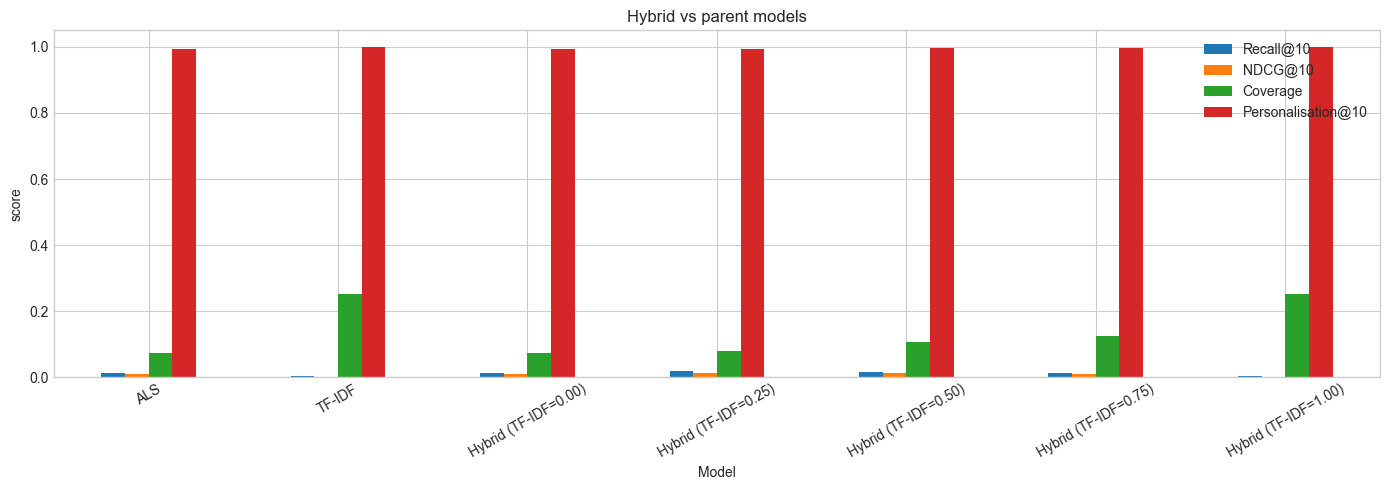

In [5]:
item_meta = wines.set_index('WineID')[['Type', 'Country']].copy()
item_meta['Type'] = item_meta['Type'].astype(str).str.lower().fillna('unknown')
item_meta['Country'] = item_meta['Country'].astype(str).str.lower().fillna('unknown')
item_signatures = {
    wine_id: {f"type:{row['Type']}", f"country:{row['Country']}"}
    for wine_id, row in item_meta.iterrows()
}


def accuracy_at_k(relevant, recommended, k):
    if k == 0:
        return 0.0
    hits = sum(1 for item in recommended[:k] if item in relevant)
    return hits / k


def recall_at_k(relevant, recommended, k):
    if not relevant:
        return 0.0
    hits = sum(1 for item in recommended[:k] if item in relevant)
    return hits / len(relevant)


def dcg_at_k(relevant, recommended, k):
    score = 0.0
    for rank, item in enumerate(recommended[:k], start=1):
        if item in relevant:
            score += 1.0 / np.log2(rank + 1)
    return score


def ndcg_at_k(relevant, recommended, k):
    ideal_hits = min(len(relevant), k)
    if ideal_hits == 0:
        return 0.0
    idcg = sum(1.0 / np.log2(rank + 1) for rank in range(1, ideal_hits + 1))
    return dcg_at_k(relevant, recommended, k) / idcg


def jaccard_distance(a, b):
    union = len(a | b)
    return 0.0 if union == 0 else 1.0 - (len(a & b) / union)


def intra_list_diversity(recommended):
    if len(recommended) < 2:
        return 0.0
    vals = []
    for i in range(len(recommended)):
        for j in range(i + 1, len(recommended)):
            vals.append(
                jaccard_distance(
                    item_signatures.get(recommended[i], {'unknown'}),
                    item_signatures.get(recommended[j], {'unknown'}),
                )
            )
    return float(np.mean(vals)) if vals else 0.0


def personalisation_at_k(recs_by_user, k=10, max_users=300, random_state=RANDOM_STATE):
    users = list(recs_by_user.keys())
    if len(users) < 2:
        return 0.0
    rng = np.random.default_rng(random_state)
    if len(users) > max_users:
        users = rng.choice(users, size=max_users, replace=False).tolist()
    top_k_sets = {user_id: set(recs_by_user[user_id][:k]) for user_id in users}
    overlaps = []
    for user_a, user_b in itertools.combinations(users, 2):
        a, b = top_k_sets[user_a], top_k_sets[user_b]
        union = len(a | b)
        overlaps.append((len(a & b) / union) if union > 0 else 0.0)
    return float(1.0 - np.mean(overlaps)) if overlaps else 0.0


def minmax_scale(scores):
    finite_scores = scores[np.isfinite(scores)]
    if finite_scores.size == 0:
        return scores
    s_min = finite_scores.min()
    s_max = finite_scores.max()
    if np.isclose(s_min, s_max):
        out = np.zeros_like(scores, dtype='float32')
        out[np.isfinite(scores)] = 1.0
        return out
    out = (scores - s_min) / (s_max - s_min)
    return out.astype('float32')


def recommend_tfidf_ids(user_id, top_k=10):
    scores = score_tfidf_user(user_id)
    if scores.size == 0:
        return []
    scores = scores.copy()
    for wine_id in train_seen.get(user_id, set()):
        item_idx = wineid_to_idx.get(wine_id)
        if item_idx is not None:
            scores[item_idx] = -np.inf
    n_valid = int(np.sum(np.isfinite(scores)))
    if n_valid == 0:
        return []
    k = min(top_k, n_valid)
    top_idx = np.argpartition(scores, -k)[-k:]
    top_idx = top_idx[np.argsort(scores[top_idx])[::-1]]
    return [int(idx_to_wineid[idx]) for idx in top_idx[:top_k]]


def recommend_als_ids(user_id, top_k=10):
    scores = score_als_user(user_id)
    if scores.size == 0:
        return []
    scores = scores.copy()
    for wine_id in als_artifact['train_seen'].get(user_id, set()):
        item_idx = als_artifact['item2idx'].get(wine_id)
        if item_idx is not None:
            scores[item_idx] = -np.inf
    n_valid = int(np.sum(np.isfinite(scores)))
    if n_valid == 0:
        return []
    k = min(top_k, n_valid)
    top_idx = np.argpartition(scores, -k)[-k:]
    top_idx = top_idx[np.argsort(scores[top_idx])[::-1]]
    return [int(als_artifact['idx2item'][idx]) for idx in top_idx[:top_k]]


def recommend_hybrid_ids(user_id, tfidf_weight=0.5, top_k=10):
    tfidf_scores = score_tfidf_user(user_id)
    als_scores = score_als_user(user_id)
    if tfidf_scores.size == 0 and als_scores.size == 0:
        return []

    combined_scores = np.zeros(len(wines), dtype='float32')
    valid_mask = np.zeros(len(wines), dtype=bool)

    if tfidf_weight > 0 and tfidf_scores.size:
        tfidf_scaled = minmax_scale(tfidf_scores)
        tfidf_mask = np.isfinite(tfidf_scaled)
        combined_scores[tfidf_mask] += tfidf_weight * tfidf_scaled[tfidf_mask]
        valid_mask |= tfidf_mask

    if tfidf_weight < 1 and als_scores.size:
        als_full = np.full(len(wines), np.nan, dtype='float32')
        for item_idx, wine_id in als_artifact['idx2item'].items():
            tfidf_idx = wineid_to_idx.get(wine_id)
            if tfidf_idx is not None:
                als_full[tfidf_idx] = als_scores[item_idx]
        als_scaled = minmax_scale(np.where(np.isnan(als_full), -np.inf, als_full))
        als_mask = np.isfinite(als_scaled)
        combined_scores[als_mask] += (1.0 - tfidf_weight) * als_scaled[als_mask]
        valid_mask |= als_mask

    combined_scores[~valid_mask] = -np.inf

    seen_ids = train_seen.get(user_id, set()) | als_artifact['train_seen'].get(user_id, set())
    for wine_id in seen_ids:
        item_idx = wineid_to_idx.get(wine_id)
        if item_idx is not None:
            combined_scores[item_idx] = -np.inf

    n_valid = int(np.sum(np.isfinite(combined_scores)))
    if n_valid == 0:
        return []
    k = min(top_k, n_valid)
    top_idx = np.argpartition(combined_scores, -k)[-k:]
    top_idx = top_idx[np.argsort(combined_scores[top_idx])[::-1]]
    return [int(idx_to_wineid[idx]) for idx in top_idx[:top_k]]


def evaluate_recommender(recommend_func, users, relevant_dict, ks=(5, 10, 20)):
    rows = []
    recs_by_user = {}
    all_top10_items = []
    max_k = max(ks)
    for user_id in users:
        relevant = relevant_dict.get(user_id, set())
        if not relevant:
            continue
        recs = recommend_func(user_id, top_k=max_k)
        if not recs:
            continue
        recs_by_user[user_id] = recs
        all_top10_items.extend(recs[:10])
        row = {'UserID': user_id}
        for k in ks:
            row[f'Accuracy@{k}'] = accuracy_at_k(relevant, recs, k)
            row[f'Recall@{k}'] = recall_at_k(relevant, recs, k)
            row[f'NDCG@{k}'] = ndcg_at_k(relevant, recs, k)
            row[f'Diversity@{k}'] = intra_list_diversity(recs[:k])
        rows.append(row)
    eval_df = pd.DataFrame(rows)
    if eval_df.empty:
        return eval_df, {}
    coverage = len(set(all_top10_items)) / len(wines) if len(wines) else 0.0
    pers = personalisation_at_k(recs_by_user, k=10, max_users=300, random_state=RANDOM_STATE)
    extras = {'Coverage': coverage, 'Personalisation@10': pers}
    return eval_df, extras


eval_users = sorted(set(test_pos['UserID']) & set(train_pos['UserID']))
model_summaries = []

for label, func in [
    ('ALS', recommend_als_ids),
    ('TF-IDF', recommend_tfidf_ids),
]:
    eval_df, extras = evaluate_recommender(func, eval_users, test_relevant)
    summary = eval_df.drop(columns='UserID').mean().to_dict()
    summary.update(extras)
    summary['Model'] = label
    model_summaries.append(summary)

for weight in HYBRID_WEIGHTS:
    label = f'Hybrid (TF-IDF={weight:.2f})'
    eval_df, extras = evaluate_recommender(
        lambda user_id, top_k, weight=weight: recommend_hybrid_ids(user_id, tfidf_weight=weight, top_k=top_k),
        eval_users,
        test_relevant,
    )
    summary = eval_df.drop(columns='UserID').mean().to_dict()
    summary.update(extras)
    summary['Model'] = label
    summary['TFIDF_weight'] = weight
    model_summaries.append(summary)

summary_df = pd.DataFrame(model_summaries).set_index('Model').round(4)
display(summary_df)

comparison_cols = ['Recall@10', 'NDCG@10', 'Coverage', 'Personalisation@10']
summary_df[comparison_cols].plot(kind='bar', figsize=(14, 5), rot=30)
plt.title('Hybrid vs parent models')
plt.ylabel('score')
plt.tight_layout()
plt.show()

## 5. Interpret the results

The hybrid works best when ALS is the main signal and TF-IDF is added in a smaller amount.

The best setting is Hybrid (TF-IDF=0.25).

Its main results are:

- Recall@10 = 0.0184
- NDCG@10 = 0.0133
- Coverage = 0.0788
- Personalisation@10 = 0.9947

This model is better than pure ALS on ranking quality and slightly better on coverage.

It is much better than pure TF-IDF on ranking quality.

This means TF-IDF helps, but only when it is used as a small extra signal.

When the TF-IDF weight gets too large, the ranking quality gets worse. Coverage goes up, but relevance goes down.

So the main conclusion is simple: for this dataset, the best hybrid is a collaborative-first model with a small content-based addition.

In [6]:
hybrid_only = summary_df[summary_df.index.str.contains('Hybrid')].copy()
if not hybrid_only.empty:
    best_hybrid = hybrid_only.sort_values(['NDCG@10', 'Recall@10'], ascending=False).head(1)
    display(best_hybrid)
    best_name = best_hybrid.index[0]
    best_weight = float(best_hybrid['TFIDF_weight'].iloc[0])
    print(f'Best hybrid setting: {best_name} (TF-IDF weight={best_weight:.2f})')

,Accuracy@5,Recall@5,NDCG@5,Diversity@5,Accuracy@10,Recall@10,NDCG@10,Diversity@10,Accuracy@20,Recall@20,NDCG@20,Diversity@20,Coverage,Personalisation@10,TFIDF_weight
Model,,,,,,,,,,,,,,,
Hybrid (TF-IDF=0.25),0.0074,0.0107,0.0107,0.2746,0.0061,0.0184,0.0133,0.2898,0.005,0.03,0.0172,0.307,0.0788,0.9947,0.25


Best hybrid setting: Hybrid (TF-IDF=0.25) (TF-IDF weight=0.25)


## 6. Business takeaway

A simple business message is this:

The hybrid model can recommend more relevant wines than either parent model alone.

ALS gives the strongest main signal. TF-IDF adds useful extra information. Together they give a better balance of relevance, coverage, and personalisation.

For this project, TF-IDF=0.25 is the best setting to present.